# Кредитный скоринг — версия 1

**Проектная смена, 9–11 класс**

Первая рабочая версия пайплайна: от сырого `train.csv` до логистической регрессии,
подбора порога и честной оценки на `late_test`.

| Что делаем | Зачем |
|------------|--------|
| Смотрим статистики и чистим данные | Модель не должна учиться на мусоре и константах |
| Делим на train / val / test / late_test | Одни и те же выборки во всех следующих версиях |
| Сэмплируем только train | Быстрее учиться; размер сэмпла потом увеличим |
| Заполняем пропуски, кодируем, масштабируем | Логрег работает с числами и чувствителен к масштабу |
| Учим логистическую регрессию | Простая модель, которую легко объяснять |
| Подбираем порог на валидации | Gini не зависит от порога; для «выдать / отказать» порог нужен |

**Данные:** только `data/train.csv` (остальные таблицы в этой версии не трогаем).

**Главная метрика ранжирования:** Gini \(= 2 \times\) ROC-AUC \(- 1\).

**Метрика после выбора порога:** F1 по классу дефолта (`target = 1`).



Структура датасета (Home Credit, переименованные колонки):

| Файл | Содержание |
|------|------------|
| `train.csv` | Основные заявки + `target` |
| `bki.csv` | Кредитная история из БКИ |
| `bki_balance.csv` | Ежемесячные статусы по БКИ |
| `previous_loan.csv` | Предыдущие заявки |
| `installments_payments.csv` | История платежей |
| `credit_card_balance.csv` | Баланс кредитных карт |
| `cash_pos_balance.csv` | POS / cash кредиты |

Ключ связи: `reco_id_curr` (id текущей заявки).

## 0. Импорты и настройки

Все «крутилки», которые можно менять руками, собраны в одной ячейке ниже.
`RANDOM_STATE` должен быть одинаковым во всех версиях ноутбука — тогда сплиты и сэмпл совпадут.


In [26]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from IPython.display import display

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# ---------------------------------------------------------------------------
# Общие константы (не менять между версиями, если нужны те же сплиты/сэмпл)
# ---------------------------------------------------------------------------
RANDOM_STATE = 42
SAMPLE_SIZE = 50_000          # размер сэмпла train; потом увеличиваем вручную

# доли выборки после очистки; сумма = 1
TRAIN_FRAC = 0.70
VAL_FRAC = 0.10
TEST_FRAC = 0.10
LATE_FRAC = 0.10

# очистка колонок
MISSING_MAX_SHARE = 0.60      # удаляем признак, если пропусков больше 50%
CONSTANT_MAX_SHARE = 0.99     # удаляем признак, если одно значение встречается >99%

# выбросы по усам боксплота (IQR)
IQR_K = 1.5                   # стандартные усы: Q1 - 1.5*IQR, Q3 + 1.5*IQR
IQR_FEW_MAX_SHARE = 0.01      # если выбросов < 1% строк — удаляем эти объекты
IQR_BOXPLOT_MAX = 10          # максимум графиков для «много выбросов»

# кодирование категорий
ONEHOT_MAX_UNIQUE = 15        # мало уникальных значений → One-Hot, иначе Ordinal/Label

# ---------------------------------------------------------------------------
PROJECT_DIR = Path('.').resolve()
DATA_PATH = PROJECT_DIR / 'data' / 'train.csv'
SPLITS_DIR = PROJECT_DIR / 'data' / 'splits'

np.random.seed(RANDOM_STATE)

print('Проект:', PROJECT_DIR)
print('Данные:', DATA_PATH)
print('Сплиты:', SPLITS_DIR)


Проект: C:\Users\user\Desktop\ПШНТ\проект\code 0
Данные: C:\Users\user\Desktop\ПШНТ\проект\code 0\data\train.csv
Сплиты: C:\Users\user\Desktop\ПШНТ\проект\code 0\data\splits


In [27]:
def gini_score(y_true, y_proba) -> float:
    """Gini = 2 * ROC-AUC - 1. Случайный классификатор даёт 0, идеальный — 1."""
    return 2 * roc_auc_score(y_true, y_proba) - 1


def classification_at_threshold(y_true, y_proba, threshold: float) -> dict:
    """Метрики уже после превращения вероятности в 0/1 по порогу."""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'F1': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


## 1. Загрузка данных

Одна строка `train.csv` = одна кредитная заявка.
`reco_id_curr` — id заявки, `target` — дефолт (1) или нет (0).


In [28]:
df = pd.read_csv(DATA_PATH)
print(f'Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов')
print('Ключ:', 'reco_id_curr' if 'reco_id_curr' in df.columns else 'нет')
print('Целевая переменная: target')
df.head()


Размер: 261,384 строк × 122 столбцов
Ключ: reco_id_curr
Целевая переменная: target


,reco_id_curr,target,contract_type_name,gender,own_car_flag,own_realty_flag,children_count,income,loan_body,annuity_payment,goods_price,type_suite_name,income_type_name,education_type_name,family_status_name,housing_type_name,population_relative_region,days_birth,days_employed,registration_timestamp,...,document_8_flag,document_9_flag,document_10_flag,document_11_flag,document_12_flag,document_13_flag,document_14_flag,document_15_flag,document_16_flag,document_17_flag,document_18_flag,document_19_flag,document_20_flag,document_21_flag,requests_bki_hour,requests_bki_day,requests_bki_week,requests_bki_month,requests_bki_qrt,requests_bki_year
0,384575,0,Cash loans,M,Y,N,2,"207,000.000","465,457.500","52,641.000","418,500.000",Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.010,-13297,-762,-637.000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,1.000,0.000,1.000
1,214010,0,Cash loans,F,Y,Y,0,"247,500.000","1,281,712.500","48,946.500","1,179,000.000",Unaccompanied,Commercial associate,Higher education,Single / not married,House / apartment,0.007,-14778,-1141,"-1,610.000",...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,1.000,0.000,3.000
2,142232,0,Cash loans,F,Y,N,0,"202,500.000","495,000.000","39,109.500","495,000.000",Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.036,-17907,-639,"-2,507.000",...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,1.000,0.000,3.000
3,389171,0,Cash loans,F,N,Y,0,"247,500.000","254,700.000","24,939.000","225,000.000",Unaccompanied,State servant,Secondary / secondary special,Widow,House / apartment,0.046,-19626,-6982,"-11,167.000",...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
4,283617,0,Cash loans,M,N,Y,0,"112,500.000","308,133.000","15,862.500","234,000.000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-20327,-1105,"-7,299.000",...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,4.000


## 2. Статистики датасета

Смотрим типы признаков, среднее / мин / макс, пропуски и баланс классов.
Пока ничего не удаляем — только смотрим.


In [29]:
print('Типы признаков:')
print(df.dtypes.value_counts())

num_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_raw = [c for c in df.columns if c not in num_cols_raw]
print(f'\nЧисловых: {len(num_cols_raw)}')
print(f'Категориальных: {len(cat_cols_raw)}')
print('Категориальные:', cat_cols_raw)


Типы признаков:
float64    65
int64      41
str        16
Name: count, dtype: int64

Числовых: 106
Категориальных: 16
Категориальные: ['contract_type_name', 'gender', 'own_car_flag', 'own_realty_flag', 'type_suite_name', 'income_type_name', 'education_type_name', 'family_status_name', 'housing_type_name', 'type_of_occupation', 'start_weekday_appr_process', 'type_of_organization', 'fondkapremon_mode', 'mode_house_type', 'mode_walls_material', 'emergency_state_mode']


In [30]:
stats = df[num_cols_raw].agg(['mean', 'min', 'max']).T
stats['n_missing'] = df[num_cols_raw].isna().sum()
stats['share_missing'] = df[num_cols_raw].isna().mean()
stats = stats.sort_values('share_missing', ascending=False)
print('Числовые признаки: среднее, мин, макс, пропуски')
stats.head(20)


Числовые признаки: среднее, мин, макс, пропуски


,mean,min,max,n_missing,share_missing
average_commonarea,0.045,0.000,1.000,182677,0.699
mode_commonarea,0.042,0.000,1.000,182677,0.699
median_commonarea,0.045,0.000,1.000,182677,0.699
non_living_apartments_mode,0.008,0.000,1.000,181529,0.694
non_living_apartments_avg,0.009,0.000,1.000,181529,0.694
non_living_apartments_medi,0.009,0.000,1.000,181529,0.694
average_living_apartments,0.101,0.000,1.000,178738,0.684
mode_living_apartments,0.106,0.000,1.000,178738,0.684
median_living_apartments,0.102,0.000,1.000,178738,0.684
average_min_floors,0.232,0.000,1.000,177428,0.679


In [31]:
stats = df[num_cols_raw].agg(['mean', 'min', 'max'])

In [32]:
stats

,reco_id_curr,target,children_count,income,loan_body,annuity_payment,goods_price,population_relative_region,days_birth,days_employed,registration_timestamp,publication_timestamp,age_own_car,mobile_flag,employee_phone_flag,work_phone_flag,mobile_contact_flag,phone_flag,email_flag,family_members__count,...,document_8_flag,document_9_flag,document_10_flag,document_11_flag,document_12_flag,document_13_flag,document_14_flag,document_15_flag,document_16_flag,document_17_flag,document_18_flag,document_19_flag,document_20_flag,document_21_flag,requests_bki_hour,requests_bki_day,requests_bki_week,requests_bki_month,requests_bki_qrt,requests_bki_year
mean,"278,231.764",0.081,0.418,"168,923.794","599,186.558","27,106.793","538,565.193",0.021,"-16,034.247","63,867.625","-4,988.039","-2,993.229",12.066,1.000,0.820,0.199,0.998,0.281,0.056,2.153,...,0.081,0.004,0.000,0.004,0.000,0.004,0.003,0.001,0.010,0.000,0.008,0.001,0.001,0.000,0.006,0.007,0.034,0.267,0.265,1.900
min,"100,002.000",0.000,0.000,"25,650.000","45,000.000","1,615.500","40,500.000",0.000,"-25,201.000","-17,912.000","-24,672.000","-7,197.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,"456,255.000",1.000,19.000,"117,000,000.000","4,050,000.000","258,025.500","4,050,000.000",0.073,"-7,489.000","365,243.000",0.000,0.000,91.000,1.000,1.000,1.000,1.000,1.000,1.000,20.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,4.000,9.000,8.000,27.000,261.000,25.000


In [33]:
print('Типы данных:')
print(df.dtypes.value_counts())

print('\nПропуски (топ-15):')
missing = df.isnull().mean().sort_values(ascending=False)
missing_top = missing[missing > 0].head(15)
print((missing_top * 100).round(1).astype(str) + '%')

print('\nОписательная статистика числовых признаков:')
df.describe().T.head(15)

Типы данных:
float64    65
int64      41
str        16
Name: count, dtype: int64

Пропуски (топ-15):
average_commonarea            69.9%
mode_commonarea               69.9%
median_commonarea             69.9%
non_living_apartments_medi    69.4%
non_living_apartments_mode    69.4%
non_living_apartments_avg     69.4%
fondkapremon_mode             68.4%
average_living_apartments     68.4%
median_living_apartments      68.4%
mode_living_apartments        68.4%
mode_min_floors               67.9%
average_min_floors            67.9%
median_min_floors             67.9%
average_years_building        66.5%
mode_years_building           66.5%
dtype: str

Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
reco_id_curr,"261,384.000","278,231.764","102,770.524","100,002.000","189,205.750","278,323.500","367,161.250","456,255.000"
target,"261,384.000",0.081,0.272,0.000,0.000,0.000,0.000,1.000
children_count,"261,384.000",0.418,0.723,0.000,0.000,0.000,1.000,19.000
income,"261,384.000","168,923.794","253,791.190","25,650.000","112,500.000","148,500.000","202,500.000","117,000,000.000"
loan_body,"261,384.000","599,186.558","402,330.880","45,000.000","270,000.000","513,531.000","808,650.000","4,050,000.000"
annuity_payment,"261,373.000","27,106.793","14,486.790","1,615.500","16,537.500","24,903.000","34,596.000","258,025.500"
goods_price,"261,152.000","538,565.193","369,284.941","40,500.000","238,500.000","450,000.000","679,500.000","4,050,000.000"
population_relative_region,"261,384.000",0.021,0.014,0.000,0.010,0.019,0.029,0.073
days_birth,"261,384.000","-16,034.247","4,365.116","-25,201.000","-19,682.000","-15,744.000","-12,407.000","-7,489.000"
days_employed,"261,384.000","63,867.625","141,317.268","-17,912.000","-2,758.000","-1,213.000",-289.000,"365,243.000"


In [37]:
cat_stats = pd.DataFrame({
    'n_unique': df[cat_cols_raw].nunique(dropna=False),
    'n_missing': df[cat_cols_raw].isna().sum(),
    'share_missing': df[cat_cols_raw].isna().mean(),
}).sort_values('share_missing', ascending=False)
print('Категориальные признаки: число уникальных значений и пропуски')
cat_stats


Категориальные признаки: число уникальных значений и пропуски


,n_unique,n_missing,share_missing
fondkapremon_mode,5,178802,0.684
mode_walls_material,8,132812,0.508
mode_house_type,4,131110,0.502
emergency_state_mode,3,123852,0.474
type_of_occupation,19,81963,0.314
type_suite_name,8,1078,0.004
own_car_flag,2,0,0.000
contract_type_name,2,0,0.000
family_status_name,6,0,0.000
education_type_name,5,0,0.000


Распределение target:
         count  share
target               
0       240274  0.919
1        21110  0.081


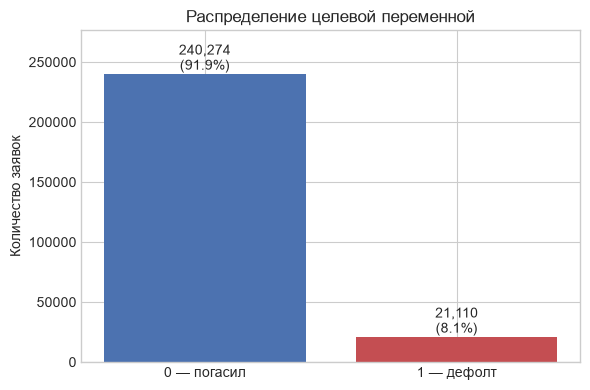

In [38]:
target_counts = df['target'].value_counts().sort_index()
target_share = df['target'].value_counts(normalize=True).sort_index()

print('Распределение target:')
print(pd.DataFrame({
    'count': target_counts,
    'share': target_share,
}))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['0 — погасил', '1 — дефолт'], target_counts.values, color=['#4c72b0', '#c44e52'])
ax.set_ylabel('Количество заявок')
ax.set_title('Распределение целевой переменной')
for bar, n, p in zip(bars, target_counts.values, target_share.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{n:,}\n({p:.1%})', ha='center', va='bottom')
ax.set_ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.show()


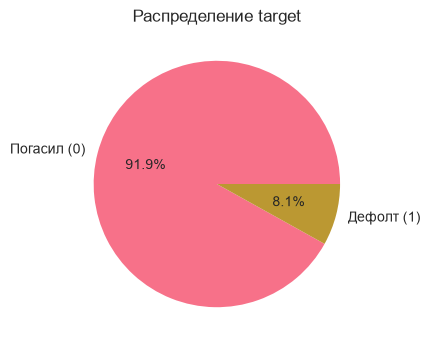

In [39]:
# Строим график распределения 0 и 1 таргете
plt.figure(figsize=(6,4))
df['target'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Погасил (0)', 'Дефолт (1)'])
plt.title('Распределение target')
plt.show()

Классы несбалансированы (~8% дефолтов). Если модель всем скажет «погасит», accuracy будет ~92%,
а дефолты она не найдёт. Поэтому дальше смотрим **Gini**, а не долю правильных ответов.


## 3. Очистка данных

Три шага:

1. **Неестественные значения** — явные ошибки или служебные маркеры (возраст 1000 лет, `days_employed = 365243`).
2. **Усы боксплота (IQR)** — мало выбросов → удаляем строки; много → рисуем графики и не трогаем автоматически.
3. **Бесполезные колонки** — много пропусков или почти константа.


### 3.1. Неестественные значения

Сначала смотрим экстремумы глазами, потом применяем правила.

Особый случай: `days_employed = 365243` — это не «человек работал 1000 лет», а маркер
«нет стажа / пенсионер» (~18% заявок). Такие строки **не удаляем**, значение заменяем на пропуск.
Иначе выкинем целый сегмент клиентов, и модель не научится их оценивать.


In [40]:
data = df.copy()

data['age_years'] = (-data['days_birth'] / 365.25)
print('Возраст, лет:  min =', data['age_years'].min(), ' max =', data['age_years'].max())
print('days_employed: min =', data['days_employed'].min(), ' max =', data['days_employed'].max())
print('  значение 365243:', int((data['days_employed'] == 365243).sum()), 'строк')
print('income:        min =', data['income'].min(), ' max =', data['income'].max())
print('  income > 10 млн:', int((data['income'] > 10_000_000).sum()))
print('children_count: min =', data['children_count'].min(), ' max =', data['children_count'].max())
print('  children_count > 10:', int((data['children_count'] > 10).sum()))
print('gender:')
print(data['gender'].value_counts(dropna=False))
print('requests_bki_qrt max =', data['requests_bki_qrt'].max(),
      '  > 10:', int((data['requests_bki_qrt'] > 10).sum()))


Возраст, лет:  min = 20.503764544832308  max = 68.99657768651609
days_employed: min = -17912  max = 365243
  значение 365243: 47104 строк
income:        min = 25650.0  max = 117000000.0
  income > 10 млн: 3
children_count: min = 0  max = 19
  children_count > 10: 8
gender:
gender
F      172103
M       89277
XNA         4
Name: count, dtype: int64
requests_bki_qrt max = 261.0   > 10: 2


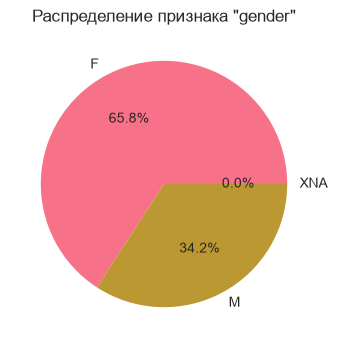

In [41]:
# Вариант 2: Более универсальный (автоматически подставит значения)
plt.figure(figsize=(6,4))
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Распределение признака "gender"')
plt.ylabel('')
plt.show()

In [42]:
n_before = len(data)

In [43]:
# Маркер «нет стажа» → пропуск, строки оставляем
n_sentinel = int((data['days_employed'] == 365243).sum())
data.loc[data['days_employed'] == 365243, 'days_employed'] = np.nan
print(f'days_employed = 365243 → NaN: {n_sentinel:,} строк (не удаляем)')

days_employed = 365243 → NaN: 47,104 строк (не удаляем)


In [44]:

# Явные ошибки: удаляем объекты
mask_bad = (
    (data['gender'] == 'XNA')
    | (data['children_count'] > 10)
    | (data['income'] > 10_000_000)
    | (data['requests_bki_qrt'] > 10)
    | (data['age_years'] < 18)
    | (data['age_years'] > 100)
)
print(f'Неестественные строки к удалению: {int(mask_bad.sum()):,}')
data = data.loc[~mask_bad].copy()

# age_years был только для проверки, в модели пока не держим
data = data.drop(columns=['age_years'])

print(f'Строк было {n_before:,}, стало {len(data):,} (удалили {n_before - len(data):,})')


Неестественные строки к удалению: 17
Строк было 261,384, стало 261,367 (удалили 17)


Строк было 261,384, стало 261,367 (удалили 17)


### 3.2. Бесполезные колонки

Удаляем признак, если:

- пропусков больше `MISSING_MAX_SHARE` (по умолчанию 60%) — заполнять такое средним почти бессмысленно;
- одно и то же значение встречается чаще `CONSTANT_MAX_SHARE` (99%) — признак почти не несёт информации.

`target` и `reco_id_curr` не трогаем.


In [45]:
protected = {'target', 'reco_id_curr'}
cols_to_drop = [] #колонки на удаление

missing_share = data.isna().mean()
many_missing = [c for c in missing_share.index
                if c not in protected and missing_share[c] > MISSING_MAX_SHARE]  #Оставляет только те, где доля пропусков больше порога (по умолчанию 0.50 = 50%)
cols_to_drop.extend(many_missing)

In [46]:
print(f'Много пропусков (>{MISSING_MAX_SHARE:.0%}): {len(many_missing)}')
print(many_missing)

Много пропусков (>60%): 17
['age_own_car', 'average_years_building', 'average_commonarea', 'average_min_floors', 'average_living_apartments', 'non_living_apartments_avg', 'mode_years_building', 'mode_commonarea', 'mode_min_floors', 'mode_living_apartments', 'non_living_apartments_mode', 'median_years_building', 'median_commonarea', 'median_min_floors', 'median_living_apartments', 'non_living_apartments_medi', 'fondkapremon_mode']


In [47]:
near_constant = [] # аля контаснтные 
for c in data.columns:
    if c in protected or c in cols_to_drop:
        continue
    top_share = data[c].value_counts(normalize=True, dropna=False).iloc[0] #количество уникальных значений в колонке
    if top_share > CONSTANT_MAX_SHARE:
        near_constant.append(c)
cols_to_drop.extend(near_constant)


print(f'\nОколоконстантные (>{CONSTANT_MAX_SHARE:.0%} одного значения): {len(near_constant)}')
print(near_constant)




Околоконстантные (>99% одного значения): 18
['mobile_flag', 'mobile_contact_flag', 'document_2_flag', 'document_4_flag', 'document_7_flag', 'document_9_flag', 'document_10_flag', 'document_11_flag', 'document_12_flag', 'document_13_flag', 'document_14_flag', 'document_15_flag', 'document_16_flag', 'document_17_flag', 'document_18_flag', 'document_19_flag', 'document_20_flag', 'document_21_flag']


In [48]:
#Константные признаки
cnt = 0
for column in data.columns:
    values_in_column = data[column].value_counts()
    if (values_in_column.max() / data.shape[0] > 0.99):
        cnt += 1
        print(column)

print(cnt)


mobile_flag
mobile_contact_flag
document_2_flag
document_4_flag
document_7_flag
document_9_flag
document_10_flag
document_11_flag
document_12_flag
document_13_flag
document_14_flag
document_15_flag
document_16_flag
document_17_flag
document_18_flag
document_19_flag
document_20_flag
document_21_flag
18


In [49]:
data = data.drop(columns=cols_to_drop)
print(f'\nКолонок после очистки: {data.shape[1]}  (удалили {len(cols_to_drop)})')


Колонок после очистки: 87  (удалили 35)


In [50]:
data.shape

(261367, 87)

### 3.3. Выбросы по усам боксплота

Для каждого **непрерывного** числового признака считаем:

\[
L = Q_1 - 1.5 \cdot IQR,\qquad U = Q_3 + 1.5 \cdot IQR,\qquad IQR = Q_3 - Q_1
\]

Значения вне \([L, U]\) — выбросы.

- Если таких строк **мало** (< 1%) — удаляем их сразу.
- Если **много** — не удаляем автоматически, рисуем боксплоты (не больше 10) для ручного анализа.

Флаги 0/1 и признаки с нулевым IQR пропускаем: усы для них бессмысленны.


**IQR** — это Interquartile Range (межквартильный размах).

**Простыми словами:**
IQR показывает разброс центральной половины данных — от 25-го процентиля до 75-го.

In [51]:
id_target = {'target', 'reco_id_curr'}
numeric_for_iqr = [] # ищем подходящие под удаление
for c in data.select_dtypes(include=[np.number]).columns: # все колонки, у которых числовой тип данных
    if c in id_target:
        continue
    nunique = data[c].nunique(dropna=True) # количество уникальных значений в колонке
    if nunique <= 2:
        continue
    numeric_for_iqr.append(c)

In [52]:
iqr_rows = []
few_outlier_mask = pd.Series(False, index=data.index)
many_outlier_cols = []

for c in numeric_for_iqr:
    s = data[c]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        continue
    lower = q1 - IQR_K * iqr
    upper = q3 + IQR_K * iqr
    is_out = (s < lower) | (s > upper)
    n_out = int(is_out.sum())
    share = n_out / len(data)
    iqr_rows.append({
        'feature': c,
        'Q1': q1,
        'Q3': q3,
        'lower': lower,
        'upper': upper,
        'n_outliers': n_out,
        'share': share,
        'action': 'drop rows' if share < IQR_FEW_MAX_SHARE else 'boxplot / keep',
    })
    if n_out == 0:
        continue
    if share < IQR_FEW_MAX_SHARE:
        few_outlier_mask = few_outlier_mask | is_out.fillna(False)
    else:
        many_outlier_cols.append((c, share, n_out))

iqr_table = pd.DataFrame(iqr_rows).sort_values('share', ascending=False)
print('Границы усов и решение по каждому признаку:')
iqr_table


Границы усов и решение по каждому признаку:


,feature,Q1,Q3,lower,upper,n_outliers,share,action
43,observes_30_count_social_circle,0.000,2.000,-3.000,5.000,16914,0.065,boxplot / keep
44,observes_60_count_social_circle,0.000,2.000,-3.000,5.000,16579,0.063,boxplot / keep
32,non_living_area_mode,0.000,0.023,-0.035,0.058,16019,0.061,boxplot / keep
41,non_living_area_medi,0.000,0.027,-0.040,0.067,14600,0.056,boxplot / keep
23,non_living_area_avg,0.000,0.028,-0.042,0.070,14071,0.054,boxplot / keep
7,days_employed,"-3,173.000",-769.000,"-6,779.000","2,837.000",12854,0.049,boxplot / keep
4,goods_price,"238,500.000","679,500.000","-423,000.000","1,341,000.000",12488,0.048,boxplot / keep
1,income,"112,500.000","202,500.000","-22,500.000","337,500.000",11938,0.046,boxplot / keep
31,mode_living_area,0.043,0.125,-0.082,0.250,11183,0.043,boxplot / keep
40,median_living_area,0.046,0.131,-0.082,0.258,10924,0.042,boxplot / keep


In [53]:
len(numeric_for_iqr)

56

In [54]:
# Список для сбора данных
iqr_rows = []

# Анализируем каждую колонку
for c in numeric_for_iqr:
    s = data[c]
    
    # Считаем квартили и IQR
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    
    # Пропускаем бесполезные
    if iqr == 0:
        continue
    
    # Считаем границы
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    # Находим выбросы
    is_out = (s < lower) | (s > upper) #сравнение массива с числом работает поэлементно
    n_out = int(is_out.sum())  #Булева маска (Series), где True = выброс, False = нормальное значение
    share = n_out / len(data) #доля выбросов
    
    # Решаем, что делать
    if share < 0.01:
        action = 'drop rows'
    else:
        action = 'boxplot'
    
    # Сохраняем строку для таблицы
    iqr_rows.append({
        'признак': c,
        'Q1': q1,
        'Q3': q3,
        'нижняя_граница': lower,
        'верхняя_граница': upper,
        'число_выбросов': n_out,
        'доля': share,
        'решение': 'drop rows' if share < IQR_FEW_MAX_SHARE else 'boxplot',
    })

# Создаем и сортируем таблицу
iqr_table = pd.DataFrame(iqr_rows)
iqr_table = iqr_table.sort_values('доля', ascending=False)


print('Границы усов и решение по каждому признаку:')
display(iqr_table)

Границы усов и решение по каждому признаку:


,признак,Q1,Q3,нижняя_граница,верхняя_граница,число_выбросов,доля,решение
43,observes_30_count_social_circle,0.000,2.000,-3.000,5.000,16914,0.065,boxplot
44,observes_60_count_social_circle,0.000,2.000,-3.000,5.000,16579,0.063,boxplot
32,non_living_area_mode,0.000,0.023,-0.035,0.058,16019,0.061,boxplot
41,non_living_area_medi,0.000,0.027,-0.040,0.067,14600,0.056,boxplot
23,non_living_area_avg,0.000,0.028,-0.042,0.070,14071,0.054,boxplot
7,days_employed,"-3,173.000",-769.000,"-6,779.000","2,837.000",12854,0.049,boxplot
4,goods_price,"238,500.000","679,500.000","-423,000.000","1,341,000.000",12488,0.048,boxplot
1,income,"112,500.000","202,500.000","-22,500.000","337,500.000",11938,0.046,boxplot
31,mode_living_area,0.043,0.125,-0.082,0.250,11183,0.043,boxplot
40,median_living_area,0.046,0.131,-0.082,0.258,10924,0.042,boxplot


In [55]:
data['external_source_2']

0        0.605
1        0.425
2        0.532
3        0.694
4        0.561
          ... 
261379   0.681
261380   0.472
261381   0.763
261382   0.166
261383   0.722
Name: external_source_2, Length: 261367, dtype: float64

In [56]:
n_before = len(data)
n_drop = int(few_outlier_mask.sum())
data = data.loc[~few_outlier_mask].copy()
print(f'Мало выбросов: удалили {n_drop:,} строк  ({n_drop / n_before:.2%})')
print(f'Строк после IQR-чистки: {len(data):,}')

many_outlier_cols = sorted(many_outlier_cols, key=lambda x: -x[1])
print(f'\nПризнаков с большой долей выбросов (не удаляем строки): {len(many_outlier_cols)}')
for c, share, n_out in many_outlier_cols[:IQR_BOXPLOT_MAX]:
    print(f'  {c:40s}  {n_out:7,}  ({share:.1%})')


Мало выбросов: удалили 2,837 строк  (1.09%)
Строк после IQR-чистки: 258,530

Признаков с большой долей выбросов (не удаляем строки): 39
  observes_30_count_social_circle            16,914  (6.5%)
  observes_60_count_social_circle            16,579  (6.3%)
  non_living_area_mode                       16,019  (6.1%)
  non_living_area_medi                       14,600  (5.6%)
  non_living_area_avg                        14,071  (5.4%)
  days_employed                              12,854  (4.9%)
  goods_price                                12,488  (4.8%)
  income                                     11,938  (4.6%)
  mode_living_area                           11,183  (4.3%)
  median_living_area                         10,924  (4.2%)


In [57]:
# Удаляем строки с редкими выбросами
rows_to_drop = []
for row in iqr_rows:
    if row['решение'] == 'drop rows':
        s = data[row['признак']]
        bad = (s < row['нижняя_граница']) | (s > row['верхняя_граница'])
        rows_to_drop.extend(data.index[bad].tolist())    #data.index[bad] — берем индексы строк, где есть выбросы .tolist() — превращаем в список .extend() — добавляем эти индексы в общий список rows_to_drop

rows_to_drop = list(set(rows_to_drop)) # ОДНА СТРОКА МОЖЕТ БЫТЬ ВЫБРОСОМ В РАЗНЫХ ПРИЗНАКАХ. УДАЛЯТЬ ПО НЕСКОЛЬКУ РАЗ МЫ ЕЕ НЕ ДОЛЖНЫ
data = data.drop(index=rows_to_drop) #Удаляем все строки, у которых есть хотя бы один редкий выброс.

print(f'Удалили {len(rows_to_drop):,} строк')

# Признаки с большим количеством выбросов
many = [row for row in iqr_rows if row['решение'] == 'boxplot']
many = sorted(many, key=lambda x: -x['доля'])

print(f'Признаков с выбросами >1%: {len(many)}')
for row in many[:10]:
    print(f"  {row['признак']:40s}  {row['число_выбросов']:7,}  ({row['доля']:.1%})")

Удалили 0 строк
Признаков с выбросами >1%: 39
  observes_30_count_social_circle            16,914  (6.5%)
  observes_60_count_social_circle            16,579  (6.3%)
  non_living_area_mode                       16,019  (6.1%)
  non_living_area_medi                       14,600  (5.6%)
  non_living_area_avg                        14,071  (5.4%)
  days_employed                              12,854  (4.9%)
  goods_price                                12,488  (4.8%)
  income                                     11,938  (4.6%)
  mode_living_area                           11,183  (4.3%)
  median_living_area                         10,924  (4.2%)


Графики ниже — только для ручного разбора. В этой версии строки с «массовыми» выбросами
не удаляем: доход, сумма кредита и число детей имеют тяжёлый правый хвост, и это часто
реальные клиенты, а не ошибки ввода.


In [58]:
len(many)

39

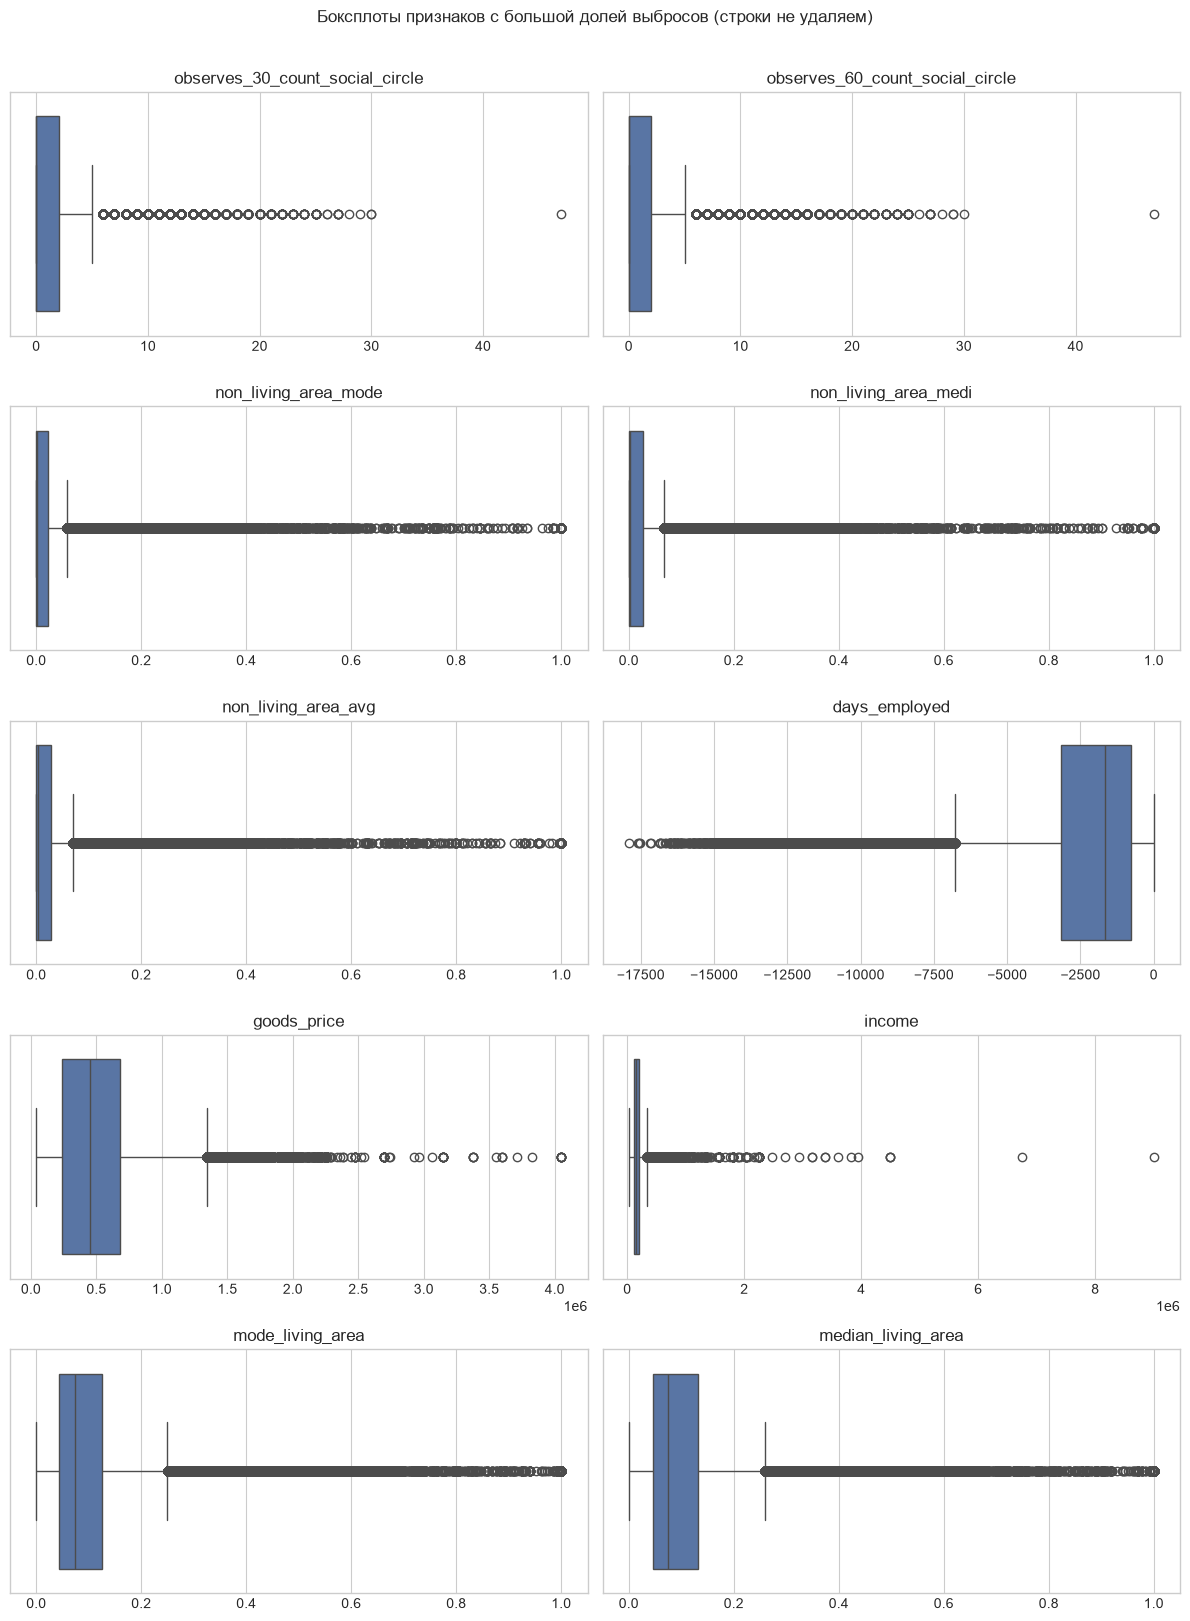

In [78]:
plot_cols = [row['признак'] for row in many[:IQR_BOXPLOT_MAX]]#IQR_BOXPLOT_MAX - максимум выбросов, у нас 10
n = len(plot_cols)
if n == 0:
    print('Нет признаков с большой долей выбросов — графики не нужны.')
else:
    n_cols = 2
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.2 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, plot_cols):
        sns.boxplot(x=data[col], ax=ax, color='#4c72b0')
        ax.set_title(col)
        ax.set_xlabel('')
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Боксплоты признаков с большой долей выбросов (строки не удаляем)', y=1.01)
    plt.tight_layout()
    plt.show()


In [59]:
print('Итог очистки:')
print(f'  строк:   {len(df):,} → {len(data):,}')
print(f'  колонок: {df.shape[1]} → {data.shape[1]}')
print(f'  доля дефолтов: {data["target"].mean():.3%}')


Итог очистки:
  строк:   261,384 → 258,530
  колонок: 122 → 87
  доля дефолтов: 8.086%


## 4. Train / val / test / late_test

Делим **очищенный** датасет один раз и сохраняем в файлы.
Все следующие версии ноутбука должны **подгружать эти файлы**, а не делить заново.

| Выборка | Доля | Зачем |
|---------|------|--------|
| **train** | 70% | Обучение (из него потом берём сэмпл) |
| **val** | 10% | Подбор гиперпараметров и порога |
| **test** | 10% | Проверка после подбора |
| **late_test** | 10% | Честная оценка в самом конце, руками не крутим |

Шафл и стратификация по `target` обязательны: в каждой части будет ~8% дефолтов.


шафл = true по умолчанию

In [60]:
# <!-- # доли выборки после очистки; сумма = 1
# TRAIN_FRAC = 0.70
# VAL_FRAC = 0.10
# TEST_FRAC = 0.10
# LATE_FRAC = 0.10 -->

In [61]:
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC + LATE_FRAC - 1.0) < 1e-9, 'доли должны суммироваться в 1'

rest, df_late = train_test_split(
    data,
    test_size=LATE_FRAC,
    stratify=data['target'],
    shuffle=True,
    random_state=RANDOM_STATE,
)
df_train, rest2 = train_test_split(
    rest,
    train_size=TRAIN_FRAC / (1 - LATE_FRAC),
    stratify=rest['target'],
    shuffle=True,
    random_state=RANDOM_STATE,
)
df_val, df_test = train_test_split(
    rest2,
    test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=rest2['target'],
    shuffle=True,
    random_state=RANDOM_STATE,
)

SPLITS_DIR.mkdir(parents=True, exist_ok=True)
splits = {
    'train': df_train,
    'val': df_val,
    'test': df_test,
    'late_test': df_late,
}
for name, part in splits.items():
    path = SPLITS_DIR / f'{name}.csv'
    part.to_csv(path, index=False)
    print(f'{name:10s}  {len(part):7,} строк  дефолтов {part["target"].mean():.3%}  → {path.name}')

print('\nГотово. Дальше (и в следующих версиях) читаем только файлы из data/splits/.')


train       180,970 строк  дефолтов 8.086%  → train.csv
val          25,853 строк  дефолтов 8.084%  → val.csv
test         25,854 строк  дефолтов 8.088%  → test.csv
late_test    25,853 строк  дефолтов 8.084%  → late_test.csv

Готово. Дальше (и в следующих версиях) читаем только файлы из data/splits/.


val          25,853 строк  дефолтов 8.084%  → val.csv


test         25,854 строк  дефолтов 8.088%  → test.csv


late_test    25,853 строк  дефолтов 8.084%  → late_test.csv

Готово. Дальше (и в следующих версиях) читаем только файлы из data/splits/.


In [62]:
# RANDOM_STATE = 42
# Сначала отделяем 10% для late_test
train_val_test, df_late = train_test_split(
    data,
    test_size=0.1,  # 10% на late_test
    stratify=data['target'],
    random_state=RANDOM_STATE
)

# Из оставшихся 90% берем 70% для train (это ~77.8% от 90%)
# train_size = 0.7 / 0.9 ≈ 0.7778
df_train, val_test = train_test_split(
    train_val_test,
    train_size=0.7778,  # 70% от ВСЕХ данных
    stratify=train_val_test['target'],
    random_state=RANDOM_STATE
)

# Из оставшихся 20% делим поровну на val и test
df_val, df_test = train_test_split(
    val_test,
    test_size=0.5,  # 10% от ВСЕХ данных
    stratify=val_test['target'],
    random_state=RANDOM_STATE
)

In [63]:
SPLITS_DIR.mkdir(parents=True, exist_ok=True) #SPLITS_DIR = PROJECT_DIR / 'data' / 'splits'
splits = {
    'train': df_train,
    'val': df_val,
    'test': df_test,
    'late_test': df_late,
}
for name, part in splits.items(): #.items() — это метод, который используется в Python для перебора пар "ключ-значение" в словарях
    path = SPLITS_DIR / f'{name}.csv'
    part.to_csv(path, index=False)
    print(f'{name:10s}  {len(part):7,} строк  дефолтов {part["target"].mean():.3%}  → {path.name}')

print('\nГотово. Дальше (и в следующих версиях) читаем только файлы из data/splits/.')


train       180,976 строк  дефолтов 8.086%  → train.csv
val          25,850 строк  дефолтов 8.085%  → val.csv
test         25,851 строк  дефолтов 8.085%  → test.csv
late_test    25,853 строк  дефолтов 8.084%  → late_test.csv

Готово. Дальше (и в следующих версиях) читаем только файлы из data/splits/.


## 5. Загрузка сплитов и сэмпл train

Сэмплируем **только train**. `val` / `test` / `late_test` остаются как в файлах.

Берём подвыборку через тот же `train_test_split`: `shuffle=True`, `stratify` по `target`, `random_state=RANDOM_STATE`.
При одном и том же зерне сэмпл совпадёт в любой версии ноутбука.


In [68]:
df_train = pd.read_csv(SPLITS_DIR / 'train.csv')
df_val = pd.read_csv(SPLITS_DIR / 'val.csv')
df_test = pd.read_csv(SPLITS_DIR / 'test.csv')
df_late = pd.read_csv(SPLITS_DIR / 'late_test.csv')

print('Загружено из data/splits/:')
for name, part in [('train', df_train), ('val', df_val), ('test', df_test), ('late_test', df_late)]:
    print(f'  {name:10s} {part.shape[0]:7,} × {part.shape[1]}') # просто красивый вывод


Загружено из data/splits/:
  train      180,976 × 87
  val         25,850 × 87
  test        25,851 × 87
  late_test   25,853 × 87


In [69]:
df_train_full = df_train.copy()

if SAMPLE_SIZE < len(df_train_full):
    df_train, _ = train_test_split(
        df_train_full,
        train_size=SAMPLE_SIZE,
        stratify=df_train_full['target'],
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    df_train = df_train.reset_index(drop=True) #reset_index(drop=True) — это сброс индексов у DataFrame


# Важно: мы используем train_test_split для уменьшения выборки, а не для разделения на train/test!

# Результат:

# df_train — 50 000 строк (сэмпл)

# _ — оставшиеся 130 970 строк (игнорируем)

print(f'train полный:   {len(df_train_full):,}')
print(f'train сэмпл:    {len(df_train):,}  (SAMPLE_SIZE = {SAMPLE_SIZE:,})')
print(f'доля дефолтов:  полный {df_train_full["target"].mean():}  |  сэмпл {df_train["target"].mean():}')
print('val / test / late_test без изменений')


train полный:   180,976
train сэмпл:    50,000  (SAMPLE_SIZE = 50,000)
доля дефолтов:  полный 0.08086155070285563  |  сэмпл 0.08086
val / test / late_test без изменений


## 6. Пропуски, кодирование категорий, масштабирование

Правило без утечки: **учим преобразования только на train**, на остальные выборки только применяем.

1. Вещественные пропуски → **медиана** (устойчивее среднего к хвостам дохода/кредита).
2. Категориальные пропуски → самое частое значение.
3. Категории с небольшим числом значений → **One-Hot**; с большим (`type_of_organization` и т.п.) → **Ordinal / Label encoding**.
4. `StandardScaler` учим на train после кодирования и применяем ко всем выборкам.


In [70]:
# TARGET = 'target'
# ID_COL = 'reco_id_curr'


# def split_xy(frame: pd.DataFrame):
#     y = frame[TARGET].astype(int)
#     X = frame.drop(columns=[c for c in (TARGET, ID_COL) if c in frame.columns])
#     return X, y


# # X_train, y_train = split_xy(dftrain)
# X_val, y_val = split_xy(df_val)
# X_test, y_test = split_xy(df_test)
# X_late, y_late = split_xy(df_late)

# num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
# cat_cols = [c for c in X_train.columns if c not in num_cols]

# low_card_cols = [c for c in cat_cols if X_train[c].nunique(dropna=True) <= ONEHOT_MAX_UNIQUE]
# high_card_cols = [c for c in cat_cols if c not in low_card_cols]

# print(f'Числовые:              {len(num_cols)}')
# print(f'One-Hot:               {len(low_card_cols)}  → {low_card_cols}')
# print(f'Ordinal/Label:         {len(high_card_cols)}  → {high_card_cols}')


In [71]:
# num_imputer = SimpleImputer(strategy='median')
# cat_imputer = SimpleImputer(strategy='most_frequent')

# X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
# X_val_num = pd.DataFrame(num_imputer.transform(X_val[num_cols]), columns=num_cols, index=X_val.index)
# X_test_num = pd.DataFrame(num_imputer.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)
# X_late_num = pd.DataFrame(num_imputer.transform(X_late[num_cols]), columns=num_cols, index=X_late.index)

# if cat_cols:
#     X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_cols]), columns=cat_cols, index=X_train.index)
#     X_val_cat = pd.DataFrame(cat_imputer.transform(X_val[cat_cols]), columns=cat_cols, index=X_val.index)
#     X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]), columns=cat_cols, index=X_test.index)
#     X_late_cat = pd.DataFrame(cat_imputer.transform(X_late[cat_cols]), columns=cat_cols, index=X_late.index)
# else:
#     X_train_cat = pd.DataFrame(index=X_train.index)
#     X_val_cat = pd.DataFrame(index=X_val.index)
#     X_test_cat = pd.DataFrame(index=X_test.index)
#     X_late_cat = pd.DataFrame(index=X_late.index)

# print('Пропуски после импутации (train):', int(X_train_num.isna().sum().sum() + X_train_cat.isna().sum().sum()))


In [72]:
# encoded_parts = {'train': [X_train_num], 'val': [X_val_num], 'test': [X_test_num], 'late': [X_late_num]}
# cat_frames = {'train': X_train_cat, 'val': X_val_cat, 'test': X_test_cat, 'late': X_late_cat}

# if low_card_cols:
#     ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
#     ohe.fit(cat_frames['train'][low_card_cols])
#     ohe_names = ohe.get_feature_names_out(low_card_cols)
#     for key, frame in cat_frames.items():
#         arr = ohe.transform(frame[low_card_cols])
#         encoded_parts[key].append(pd.DataFrame(arr, columns=ohe_names, index=frame.index))
#     print(f'One-Hot: {len(low_card_cols)} колонок → {len(ohe_names)}')
# else:
#     print('One-Hot: нет колонок')

# if high_card_cols:
#     ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
#     ord_enc.fit(cat_frames['train'][high_card_cols])
#     for key, frame in cat_frames.items():
#         arr = ord_enc.transform(frame[high_card_cols])
#         encoded_parts[key].append(pd.DataFrame(arr, columns=high_card_cols, index=frame.index))
#     print(f'Ordinal/Label: {high_card_cols}')
# else:
#     print('Ordinal/Label: нет колонок')


# def _concat(key):
#     return pd.concat(encoded_parts[key], axis=1)


# X_train_enc = _concat('train')
# X_val_enc = _concat('val')
# X_test_enc = _concat('test')
# X_late_enc = _concat('late')
# print('Размер после кодирования (train):', X_train_enc.shape)


In [67]:
# from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
# from sklearn.impute import SimpleImputer

# TARGET = 'target'
# ID_COL = 'reco_id_curr'

# def split_xy(frame):
#     y = frame[TARGET].astype(int)
#     X = frame.drop(columns=[TARGET, ID_COL], errors='ignore')
#     return X, y

# # Разбиваем
# X_train, y_train = split_xy(df_train)
# X_val, y_val = split_xy(df_val)
# X_test, y_test = split_xy(df_test)
# X_late, y_late = split_xy(df_late)

# # Типы колонок
# num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
# cat_cols = [c for c in X_train.columns if c not in num_cols]

# # Делим категории по числу уникальных
# low_card_cols = [c for c in cat_cols if X_train[c].nunique(dropna=True) <= ONEHOT_MAX_UNIQUE]
# high_card_cols = [c for c in cat_cols if c not in low_card_cols]

# print(f'Числовые: {len(num_cols)}')
# print(f'One-Hot: {len(low_card_cols)} → {low_card_cols}')
# print(f'Ordinal: {len(high_card_cols)} → {high_card_cols}')

# # Импутация
# num_imp = SimpleImputer(strategy='median')
# cat_imp = SimpleImputer(strategy='most_frequent')

# # Функция обработки одного датафрейма
# def process_split(X, fit=False):
#     # Числовая часть
#     num_data = num_imp.fit_transform(X[num_cols]) if fit else num_imp.transform(X[num_cols])
#     num_part = pd.DataFrame(num_data, columns=num_cols, index=X.index)
    
#     # Категориальная часть
#     cat_data = cat_imp.fit_transform(X[cat_cols]) if fit else cat_imp.transform(X[cat_cols])
#     cat_part = pd.DataFrame(cat_data, columns=cat_cols, index=X.index)
    
#     # One-Hot
#     ohe_data = ohe.fit_transform(cat_part[low_card_cols]) if fit else ohe.transform(cat_part[low_card_cols])
#     ohe_cols = ohe.get_feature_names_out(low_card_cols)
#     ohe_part = pd.DataFrame(ohe_data, columns=ohe_cols, index=X.index)
    
#     # Ordinal
#     ord_data = ord_enc.fit_transform(cat_part[high_card_cols]) if fit else ord_enc.transform(cat_part[high_card_cols])
#     ord_part = pd.DataFrame(ord_data, columns=high_card_cols, index=X.index)
    
#     return pd.concat([num_part, ohe_part, ord_part], axis=1)

# # Обучаем кодировщики на train
# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# # Применяем
# X_train_enc = process_split(X_train, fit=True)
# X_val_enc = process_split(X_val, fit=False)
# X_test_enc = process_split(X_test, fit=False)
# X_late_enc = process_split(X_late, fit=False)

# print(f'Размер после кодирования (train): {X_train_enc.shape}')

Числовые: 70
One-Hot: 13 → ['contract_type_name', 'gender', 'own_car_flag', 'own_realty_flag', 'type_suite_name', 'income_type_name', 'education_type_name', 'family_status_name', 'housing_type_name', 'start_weekday_appr_process', 'mode_house_type', 'mode_walls_material', 'emergency_state_mode']
Ordinal: 2 → ['type_of_occupation', 'type_of_organization']
Размер после кодирования (train): (50000, 131)


In [73]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

TARGET = 'target'
ID_COL = 'reco_id_curr'

def split_xy(frame):
    y = frame[TARGET].astype(int)
    X = frame.drop(columns=[TARGET, ID_COL], errors='ignore')
    return X, y

# Разбиваем
X_train, y_train = split_xy(df_train)
X_val, y_val = split_xy(df_val)
X_test, y_test = split_xy(df_test)
X_late, y_late = split_xy(df_late)

# Типы колонок
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

# Делим категории по числу уникальных
low_card_cols = [c for c in cat_cols if X_train[c].nunique(dropna=True) <= ONEHOT_MAX_UNIQUE]
high_card_cols = [c for c in cat_cols if c not in low_card_cols]

print(f'Числовые: {len(num_cols)}')
print(f'One-Hot: {len(low_card_cols)} → {low_card_cols}')
print(f'Ordinal: {len(high_card_cols)} → {high_card_cols}')

# Обучаем кодировщики на train
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Функция обработки одного датафрейма
def process_split(X, fit=False):
    # Числовая часть (без импутации)
    num_part = X[num_cols]
    
    # Категориальная часть (без импутации)
    cat_part = X[cat_cols]
    
    # One-Hot
    ohe_data = ohe.fit_transform(cat_part[low_card_cols]) if fit else ohe.transform(cat_part[low_card_cols])
    ohe_cols = ohe.get_feature_names_out(low_card_cols)
    ohe_part = pd.DataFrame(ohe_data, columns=ohe_cols, index=X.index)
    
    # Ordinal
    ord_data = ord_enc.fit_transform(cat_part[high_card_cols]) if fit else ord_enc.transform(cat_part[high_card_cols])
    ord_part = pd.DataFrame(ord_data, columns=high_card_cols, index=X.index)
    
    return pd.concat([num_part, ohe_part, ord_part], axis=1)

# Применяем
X_train_enc = process_split(X_train, fit=True)
X_val_enc = process_split(X_val, fit=False)
X_test_enc = process_split(X_test, fit=False)
X_late_enc = process_split(X_late, fit=False)

print(f'Размер после кодирования (train): {X_train_enc.shape}')

Числовые: 70
One-Hot: 13 → ['contract_type_name', 'gender', 'own_car_flag', 'own_realty_flag', 'type_suite_name', 'income_type_name', 'education_type_name', 'family_status_name', 'housing_type_name', 'start_weekday_appr_process', 'mode_house_type', 'mode_walls_material', 'emergency_state_mode']
Ordinal: 2 → ['type_of_occupation', 'type_of_organization']
Размер после кодирования (train): (50000, 135)


In [21]:
scaler = StandardScaler()
scaler.fit(X_train_enc)

X_train_sc = pd.DataFrame(scaler.transform(X_train_enc), columns=X_train_enc.columns, index=X_train_enc.index)
X_val_sc = pd.DataFrame(scaler.transform(X_val_enc), columns=X_val_enc.columns, index=X_val_enc.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns, index=X_test_enc.index)
X_late_sc = pd.DataFrame(scaler.transform(X_late_enc), columns=X_late_enc.columns, index=X_late_enc.index)

print('Scaler выучен на train. mean≈0, std≈1 на train:')
print('  mean abs:', np.abs(X_train_sc.mean()).mean())
print('  std mean:', X_train_sc.std().mean())


Scaler выучен на train. mean≈0, std≈1 на train:
  mean abs: 9.915333860089031e-17
  std mean: 1.0000100001500023


## 7. Логистическая регрессия

Гиперпараметры — в словаре **до** обучения. Меняете значения, перезапускаете ячейки 7–9, смотрите Gini на **val**.

Без GridSearch: подбор руками, ориентир — валидация, не тест.


In [22]:
# Крутилки модели. Меняйте здесь, затем перезапустите обучение и валидацию.
LOGREG_PARAMS = {
    'C': 1.0,                  # меньше C → сильнее регуляризация
    'penalty': 'l2',
    'solver': 'lbfgs',         # для l1 возьмите solver='saga' и больше max_iter
    'max_iter': 1000,
    'class_weight': 'balanced',  # None или 'balanced'; при 8% дефолтов balanced обычно полезен
}

model = LogisticRegression(**LOGREG_PARAMS, random_state=RANDOM_STATE)
model.fit(X_train_sc, y_train)

proba_train = model.predict_proba(X_train_sc)[:, 1]
proba_val = model.predict_proba(X_val_sc)[:, 1]

print('Параметры:', LOGREG_PARAMS)
print(f'Gini  train: {gini_score(y_train, proba_train):.4f}')
print(f'Gini  val:   {gini_score(y_val, proba_val):.4f}')
print('(Если train сильно выше val — модель переобучилась, уменьшите C.)')


Параметры: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1000, 'class_weight': 'balanced'}
Gini  train: 0.4915
Gini  val:   0.4726
(Если train сильно выше val — модель переобучилась, уменьшите C.)


## 8. Инференс на test

Когда Gini на val вас устраивает — один раз смотрим test.
Тест не используем, чтобы заново крутить `LOGREG_PARAMS`.


In [23]:
proba_test = model.predict_proba(X_test_sc)[:, 1]
print(f'Gini  test: {gini_score(y_test, proba_test):.4f}')
print(f'ROC-AUC test: {roc_auc_score(y_test, proba_test):.4f}')


Gini  test: 0.4790
ROC-AUC test: 0.7395


## 9. Калибровка: подбор порога

Gini и ROC-AUC оценивают **сортировку** клиентов по риску и **не зависят от порога**.

Чтобы сказать «кредит выдаём / отказываем», нужна вероятность → 0/1. Это и есть простой вариант калибровки на первой версии.

**Какую метрику смотреть после порога?** Accuracy снова обманет (~92% «всегда 0»).
После выбора порога смотрим **F1 по дефолту**: это баланс

- **Recall** — какую долю реальных дефолтов поймали (банку дорого пропустить);
- **Precision** — насколько точны отказы (дорого отказать хорошему клиенту).

Порог подбираем **на val**, затем применяем к test.


In [24]:
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
rows = []
for t in thresholds:
    m = classification_at_threshold(y_val, proba_val, t)
    rows.append(m)

thr_table = pd.DataFrame(rows).set_index('threshold')
print('Метрики на val при разных порогах:')
display(thr_table.style.format('{:.3f}').background_gradient(subset=['F1'], cmap='YlGn'))

best_threshold = float(thr_table['F1'].idxmax())
print(f'\nЛучший порог по F1 на val: {best_threshold:.2f}  (F1 = {thr_table.loc[best_threshold, "F1"]:.3f})')


Метрики на val при разных порогах:


,F1,Precision,Recall
threshold,,,
0.100000,0.152,0.082,0.998
0.150000,0.157,0.085,0.990
0.200000,0.165,0.090,0.972
0.250000,0.177,0.098,0.951
0.300000,0.190,0.106,0.914
0.350000,0.205,0.116,0.865
0.400000,0.222,0.128,0.807
0.450000,0.237,0.141,0.739
0.500000,0.256,0.158,0.669



Лучший порог по F1 на val: 0.65  (F1 = 0.280)


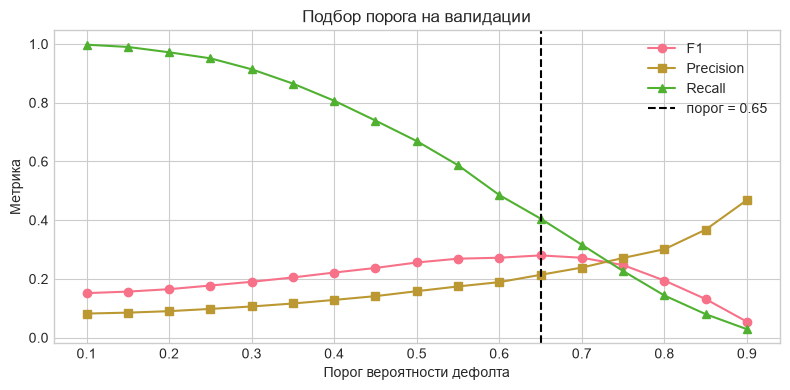

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thr_table.index, thr_table['F1'], marker='o', label='F1')
ax.plot(thr_table.index, thr_table['Precision'], marker='s', label='Precision')
ax.plot(thr_table.index, thr_table['Recall'], marker='^', label='Recall')
ax.axvline(best_threshold, color='black', linestyle='--', label=f'порог = {best_threshold:.2f}')
ax.set_xlabel('Порог вероятности дефолта')
ax.set_ylabel('Метрика')
ax.set_title('Подбор порога на валидации')
ax.legend()
plt.tight_layout()
plt.show()


Test при пороге, выбранном на val:
  Gini      0.4790   (от порога не зависит)
  F1        0.2865
  Precision 0.2194
  Recall    0.4127


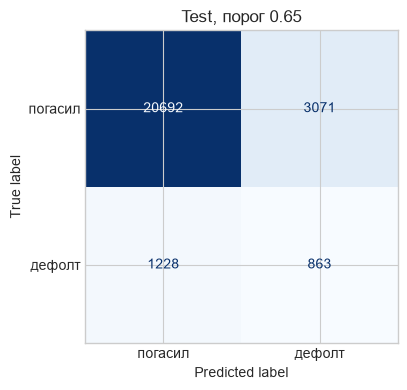

In [26]:
test_at_thr = classification_at_threshold(y_test, proba_test, best_threshold)
print('Test при пороге, выбранном на val:')
print(f'  Gini      {gini_score(y_test, proba_test):.4f}   (от порога не зависит)')
print(f'  F1        {test_at_thr["F1"]:.4f}')
print(f'  Precision {test_at_thr["Precision"]:.4f}')
print(f'  Recall    {test_at_thr["Recall"]:.4f}')

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, (proba_test >= best_threshold).astype(int)),
    display_labels=['погасил', 'дефолт'],
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Test, порог {best_threshold:.2f}')
plt.tight_layout()
plt.show()


## 10. Late test — финальная оценка

Эту выборку не использовали ни при обучении, ни при подборе `C`, ни при выборе порога.
Если Gini и F1 близки к test — пайплайн не подогнан под одну случайную выборку.


In [27]:
proba_late = model.predict_proba(X_late_sc)[:, 1]
late_at_thr = classification_at_threshold(y_late, proba_late, best_threshold)

print('Late test:')
print(f'  Gini      {gini_score(y_late, proba_late):.4f}')
print(f'  F1        {late_at_thr["F1"]:.4f}   (порог {best_threshold:.2f}, выбран на val)')
print(f'  Precision {late_at_thr["Precision"]:.4f}')
print(f'  Recall    {late_at_thr["Recall"]:.4f}')


Late test:
  Gini      0.4884
  F1        0.2981   (порог 0.65, выбран на val)
  Precision 0.2294
  Recall    0.4254


In [28]:
summary = pd.DataFrame([
    {
        'split': 'train (сэмпл)',
        'n': len(y_train),
        'Gini': gini_score(y_train, proba_train),
        'F1': classification_at_threshold(y_train, proba_train, best_threshold)['F1'],
    },
    {
        'split': 'val',
        'n': len(y_val),
        'Gini': gini_score(y_val, proba_val),
        'F1': classification_at_threshold(y_val, proba_val, best_threshold)['F1'],
    },
    {
        'split': 'test',
        'n': len(y_test),
        'Gini': gini_score(y_test, proba_test),
        'F1': test_at_thr['F1'],
    },
    {
        'split': 'late_test',
        'n': len(y_late),
        'Gini': gini_score(y_late, proba_late),
        'F1': late_at_thr['F1'],
    },
]).set_index('split')

print('Сводка версии 1')
summary


Сводка версии 1


,n,Gini,F1
split,,,
train (сэмпл),50000,0.492,0.293
val,25853,0.473,0.280
test,25854,0.479,0.286
late_test,25853,0.488,0.298


### Что запомнить из v1

1. Сплиты лежат в `data/splits/` — следующие версии только читают их.
2. Сэмпл train задаётся `SAMPLE_SIZE` и `RANDOM_STATE`; val/test/late_test не сэмплируем.
3. Импьютер, энкодеры и `StandardScaler` учатся только на train.
4. Гиперпараметры логрега — словарь `LOGREG_PARAMS`, качество смотрим на val.
5. Gini — про ранжирование. После порога смотрим F1 (и глазами precision/recall).
